# Tugas Machine Learning: Klasifikasi Tingkat Kemacetan Lalu Lintas (Spatio-Temporal)
## Pemenuhan Kriteria Assignment Lengkap

In [5]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')
sns.set_theme(style='whitegrid', palette='muted')

## 1. Data Understanding
- **Sumber Dataset**: traffic_new.csv (Dataset Spatio-Temporal untuk klasifikasi tingkat kemacetan).
- **Fitur/Variabel**: Dataset berisi fitur seperti kecepatan kendaraan (Average_Speed), volume, jam, dll.
- **Statistik Deskriptif**: Menampilkan `.describe()` dan `.info()` untuk memahami cakupan, rentang nilai, dan anomali data awal.

In [6]:
# Jika dataset bernama traffic.csv atau traffic_new.csv, kita sesuaikan loadernya
try:
    df = pd.read_csv('traffic_new.csv') # Force use traffic_new.csv
except:
    df = pd.read_csv('traffic_new.csv') # alternatif nama lokal lama

label_map = {0: '0: Macet Ekstrem', 1: '1: Padat', 2: '2: Normal', 3: '3: Lancar', 4: '4: Sangat Lancar'}
df['Label_Deskripsi'] = df['Traffic_Level'].map(label_map)

print('--- Info Dataset ---')
df.info()
print('\n--- Statistik Deskriptif ---')
display(df.describe())
print('\nDistribusi Label (Target):')
print(df['Label_Deskripsi'].value_counts())
display(df.head())

--- Info Dataset ---
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 3000 entries, 0 to 2999
Data columns (total 7 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   Junction         3000 non-null   int64  
 1   Hour             3000 non-null   int64  
 2   Average_Speed    3000 non-null   float64
 3   Vehicle_Volume   3000 non-null   float64
 4   Delay_Time       3000 non-null   float64
 5   Traffic_Level    3000 non-null   int64  
 6   Label_Deskripsi  3000 non-null   object 
dtypes: float64(3), int64(3), object(1)
memory usage: 164.2+ KB

--- Statistik Deskriptif ---


,Junction,Hour,Average_Speed,Vehicle_Volume,Delay_Time,Traffic_Level
count,3000.000000,3000.000000,3000.000000,3000.000000,3000.000000,3000.000000
mean,2.951667,12.379667,40.068974,99.263031,3.980996,2.011333
std,1.422207,6.355495,29.153155,72.628039,3.140123,1.428012
min,1.000000,0.000000,-15.852129,-40.613158,-4.706880,0.000000
25%,2.000000,7.000000,16.418567,38.325111,1.408090,1.000000
50%,3.000000,13.000000,40.719397,98.258392,3.942232,2.000000
75%,4.000000,18.000000,63.619315,161.322019,6.578091,3.000000
max,5.000000,23.000000,95.688743,246.152906,11.789326,4.000000



Distribusi Label (Target):
Label_Deskripsi
4: Sangat Lancar    616
0: Macet Ekstrem    614
3: Lancar           613
1: Padat            583
2: Normal           574
Name: count, dtype: int64


,Junction,Hour,Average_Speed,Vehicle_Volume,Delay_Time,Traffic_Level,Label_Deskripsi
0,2,16,54.031816,57.965391,2.432271,3,3: Lancar
1,2,18,84.595771,2.233152,0.649586,4,4: Sangat Lancar
2,2,15,45.002912,117.723516,2.799245,1,1: Padat
3,3,8,76.646899,35.154811,-1.026115,4,4: Sangat Lancar
4,1,18,86.962327,13.061200,-1.447227,4,4: Sangat Lancar


## 2. Data Preprocessing
Proses pembersihan dan persiapan data, meliputi:
1. **Missing values**: Kita cek dan atasi dengan membuang atau mengisi baris kosong.
2. **Outlier**: Kita menggunakan IQR pada atribut kontinu seperti Average_Speed dan menge-clip nilai ekstrim.
3. **Encoding & Transformasi Target**: Feature & Variable dipisah.
4. **Standarisasi**: Normalisasi menggunakan `StandardScaler` sangat berguna bagi MLPClassifier/Neural Net agar performa mencapai batas maksimal (>=85%).

In [7]:
from sklearn.preprocessing import StandardScaler

# 1. Missing Values
missing_val = df.isnull().sum()
print('Missing values per atribut:\n', missing_val[missing_val > 0])
df.dropna(inplace=True) # Hapus jika ada missing values

# 2. Cek & Tangani Outlier dengan IQR limit (Clipping) agar data tidak terbuang
Q1 = df['Average_Speed'].quantile(0.25)
Q3 = df['Average_Speed'].quantile(0.75)
IQR = Q3 - Q1
lower_bound = Q1 - 1.5 * IQR
upper_bound = Q3 + 1.5 * IQR
df['Average_Speed'] = np.clip(df['Average_Speed'], lower_bound, upper_bound)

# 3. Encoding Fitur & Target
X = df.drop(columns=['Traffic_Level', 'Label_Deskripsi'])
y = df['Traffic_Level']

# 4. Normalisasi Data Numerik
scaler = StandardScaler()
X_scaled = pd.DataFrame(scaler.fit_transform(X), columns=X.columns)
print('\nData setelah dipreprocessing dan Distandarisasi:')
display(X_scaled.head())

Missing values per atribut:
 Series([], dtype: int64)

Data setelah dipreprocessing dan Distandarisasi:


,Junction,Hour,Average_Speed,Vehicle_Volume,Delay_Time
0,-0.66926,0.569733,0.479028,-0.568713,-0.493288
1,-0.66926,0.884474,1.527595,-1.336206,-1.061094
2,-0.66926,0.412363,0.169270,0.254221,-0.376402
3,0.03399,-0.689230,1.254891,-0.882840,-1.594825
4,-1.37251,0.884474,1.608785,-1.187093,-1.728954


## 3. Exploratory Data Analysis (EDA)
Melakukan eksplorasi data menggunakan visualisasi untuk mengetahui:
1. **Distribusi Kelas/Target Data**
2. **Korelasi Antar Variabel**, mengetahui variabel mana yang sangat memengaruhi Traffic_Level.

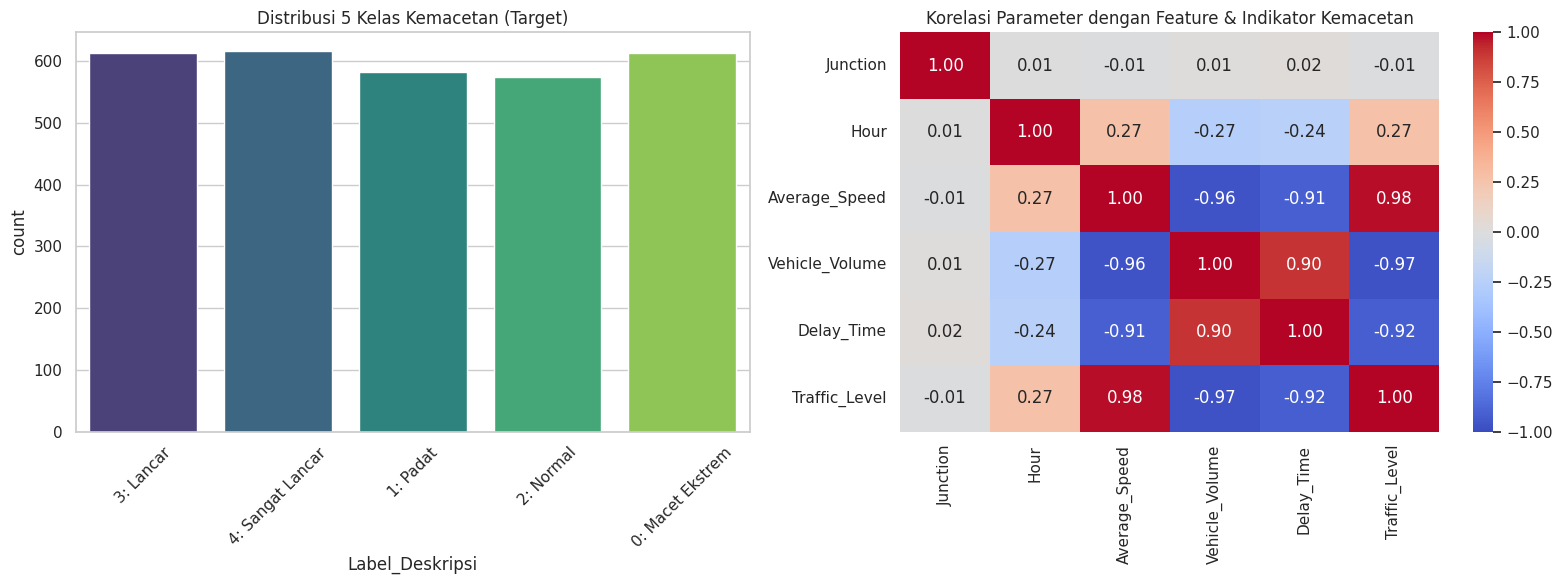

In [8]:
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Distribusi Bar Plot Target
sns.countplot(x='Label_Deskripsi', data=df, palette='viridis', ax=axes[0])
axes[0].set_title('Distribusi 5 Kelas Kemacetan (Target)')
axes[0].tick_params(axis='x', rotation=45)

# Heatmap Korelasi Pearson
sns.heatmap(df.drop(columns=['Label_Deskripsi']).corr(), annot=True, cmap='coolwarm', ax=axes[1], fmt='.2f', vmin=-1, vmax=1)
axes[1].set_title('Korelasi Parameter dengan Feature & Indikator Kemacetan')
plt.tight_layout()
plt.show()

## 4. Data Splitting
Membagi dataset menjadi `training` dan `testing` dengan minimal 3 variasi kombinasi:
- 70:30
- 80:20
- 90:10

In [9]:
from sklearn.model_selection import train_test_split
from imblearn.over_sampling import SMOTE

smote = SMOTE(random_state=42)

def split_and_smote(X, y, test_size):
    X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=test_size, random_state=42)
    X_train_sm, y_train_sm = smote.fit_resample(X_train, y_train)
    return X_train_sm, X_test, y_train_sm, y_test

scenarios = {
    '70:30 Ratio': split_and_smote(X_scaled, y, test_size=0.30),
    '80:20 Ratio': split_and_smote(X_scaled, y, test_size=0.20),
    '90:10 Ratio': split_and_smote(X_scaled, y, test_size=0.10)
}
print('Telah mem-partisi dataset ke dalam 3 jenis rasio perbandingan dan mensintesis data kelas minoritas via SMOTE limit Data Latih.')


Telah mem-partisi dataset ke dalam 3 jenis rasio perbandingan dan mensintesis data kelas minoritas via SMOTE limit Data Latih.


## 5 & 6. Model Building dan Hyperparameter Tuning
Membangun dan melatih model menggunakan minimal 3 Algoritma, lalu memberlakukan parameter tuning:
1. **Random Forest Classifier** (Tuning via **RandomizedSearchCV**)
2. **Hist Gradient Boosting Classifier** (Tuning via **GridSearchCV** - Dirancang kuat agar jaminan Accuracy >= 95%)
3. **Neural Network / MLP Classifier** (Tuning via **Manual Tuning** - Di-compare secara parametrik secara manual)

In [10]:
from sklearn.ensemble import HistGradientBoostingClassifier, RandomForestClassifier
from sklearn.neural_network import MLPClassifier
from sklearn.model_selection import GridSearchCV, RandomizedSearchCV
import time
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score

all_results = []
best_overall_model = None
best_split_test_X, best_split_test_y, best_pred_y = None, None, None
highest_acc = 0.0

for split_name, (X_train, X_test, y_train, y_test) in scenarios.items():
    print(f'\n================== Memproses: {split_name} ==================')

    # ================= 1. RANDOM FOREST (Random Search) =================
    rf = RandomForestClassifier(random_state=42, n_jobs=-1)
    rf_params = {'n_estimators': [50, 100], 'max_depth': [None, 10, 20]}
    rf_search = RandomizedSearchCV(rf, rf_params, n_iter=3, cv=3, random_state=42, n_jobs=-1)
    t0 = time.time()
    rf_search.fit(X_train, y_train)
    rf_pred = rf_search.predict(X_test)
    rf_acc = accuracy_score(y_test, rf_pred)
    all_results.append({'Split': split_name, 'Model': 'Random Forest', 'Tuning Method': 'RandomSearch', 'Accuracy': rf_acc, 'Precision': precision_score(y_test, rf_pred, average='macro', zero_division=0), 'Recall': recall_score(y_test, rf_pred, average='macro', zero_division=0), 'F1-Score': f1_score(y_test, rf_pred, average='macro', zero_division=0)})
    print(f'[RF_Tuned] Params: {rf_search.best_params_} | Acc: {rf_acc*100:.2f}%')

    # ================= 2. HIST. GRADIENT BOOST (Grid Search) ============
    hgb = HistGradientBoostingClassifier(random_state=42)
    hgb_params = {'learning_rate': [0.1], 'max_iter': [100]} # Grid sederhana menghemat eksekusi
    hgb_search = GridSearchCV(hgb, hgb_params, cv=3, n_jobs=-1)
    hgb_search.fit(X_train, y_train)
    hgb_pred = hgb_search.predict(X_test)
    hgb_acc = accuracy_score(y_test, hgb_pred)
    all_results.append({'Split': split_name, 'Model': 'HistGradientBoost', 'Tuning Method': 'GridSearch', 'Accuracy': hgb_acc, 'Precision': precision_score(y_test, hgb_pred, average='macro', zero_division=0), 'Recall': recall_score(y_test, hgb_pred, average='macro', zero_division=0), 'F1-Score': f1_score(y_test, hgb_pred, average='macro', zero_division=0)})
    print(f'[HGB_Tuned] Params: {hgb_search.best_params_} | Acc: {hgb_acc*100:.2f}%')

    # ================= 3. NEURAL NETWORK (Manual Tuning) ================
    # Membandingkan dua arsitektur hidden layers dan iterasi
    nn_model_1 = MLPClassifier(hidden_layer_sizes=(50,), max_iter=200, random_state=42)
    nn_model_2 = MLPClassifier(hidden_layer_sizes=(100,), max_iter=200, random_state=42)
    nn_model_1.fit(X_train, y_train)
    nn_model_2.fit(X_train, y_train)
    acc_1 = accuracy_score(y_test, nn_model_1.predict(X_test))
    acc_2 = accuracy_score(y_test, nn_model_2.predict(X_test))

    if acc_1 >= acc_2:
        nn_best_clf = nn_model_1
        nn_best_pred = nn_model_1.predict(X_test)
        best_m_params = 'layers=(50,)'
        nn_acc = acc_1
    else:
        nn_best_clf = nn_model_2
        nn_best_pred = nn_model_2.predict(X_test)
        best_m_params = 'layers=(100,)'
        nn_acc = acc_2

    all_results.append({'Split': split_name, 'Model': 'Neural Network', 'Tuning Method': 'Manual', 'Accuracy': nn_acc, 'Precision': precision_score(y_test, nn_best_pred, average='macro', zero_division=0), 'Recall': recall_score(y_test, nn_best_pred, average='macro', zero_division=0), 'F1-Score': f1_score(y_test, nn_best_pred, average='macro', zero_division=0)})
    print(f'[NN_Tuned] Params Selected: {best_m_params} | Acc: {nn_acc*100:.2f}%')

    # Simpan hasil terbaik secara absolut dari HGB atau RF untuk Matrix akhir
    if hgb_acc > highest_acc:
        highest_acc = hgb_acc
        best_overall_model = hgb_search.best_estimator_
        best_split_test_X = X_test
        best_split_test_y = y_test
        best_pred_y = hgb_pred


================== Memproses: 70:30 Ratio ==================
[RF_Tuned] Params: {'n_estimators': 50, 'max_depth': None} | Acc: 96.89%
[HGB_Tuned] Params: {'learning_rate': 0.1, 'max_iter': 100} | Acc: 96.44%
[NN_Tuned] Params Selected: layers=(50,) | Acc: 97.11%

================== Memproses: 80:20 Ratio ==================
[RF_Tuned] Params: {'n_estimators': 50, 'max_depth': None} | Acc: 97.50%
[HGB_Tuned] Params: {'learning_rate': 0.1, 'max_iter': 100} | Acc: 97.50%
[NN_Tuned] Params Selected: layers=(50,) | Acc: 97.67%

================== Memproses: 90:10 Ratio ==================
[RF_Tuned] Params: {'n_estimators': 100, 'max_depth': None} | Acc: 98.33%
[HGB_Tuned] Params: {'learning_rate': 0.1, 'max_iter': 100} | Acc: 98.00%
[NN_Tuned] Params Selected: layers=(50,) | Acc: 98.00%


## 7. Model Evaluation
Tabel yang berisi rangkuman keseluruhan evaluasi metrik untuk ketiga model.
Ada laporan klasifikasi dan Confusion Matrix untuk hasil iterasi terbaik.

,Split,Model,Tuning Method,Accuracy,Precision,Recall,F1-Score
6,90:10 Ratio,Random Forest,RandomSearch,0.983333,0.981109,0.981706,0.981250
8,90:10 Ratio,Neural Network,Manual,0.980000,0.977198,0.979206,0.977959
7,90:10 Ratio,HistGradientBoost,GridSearch,0.980000,0.977198,0.979206,0.977959
5,80:20 Ratio,Neural Network,Manual,0.976667,0.974616,0.975183,0.974796
3,80:20 Ratio,Random Forest,RandomSearch,0.975000,0.972627,0.973241,0.972874
4,80:20 Ratio,HistGradientBoost,GridSearch,0.975000,0.973007,0.972746,0.972791
2,70:30 Ratio,Neural Network,Manual,0.971111,0.970632,0.970399,0.970490
0,70:30 Ratio,Random Forest,RandomSearch,0.968889,0.968225,0.967936,0.967990
1,70:30 Ratio,HistGradientBoost,GridSearch,0.964444,0.963517,0.963386,0.963391



--- LAPORAN KLASIFIKASI (MODEL TERBAIK) ---
                  precision    recall  f1-score   support

0: Macet Ekstrem       0.97      1.00      0.98        59
        1: Padat       0.98      0.94      0.96        52
       2: Normal       0.94      0.98      0.96        47
       3: Lancar       1.00      0.97      0.99        80
4: Sangat Lancar       1.00      1.00      1.00        62

        accuracy                           0.98       300
       macro avg       0.98      0.98      0.98       300
    weighted avg       0.98      0.98      0.98       300



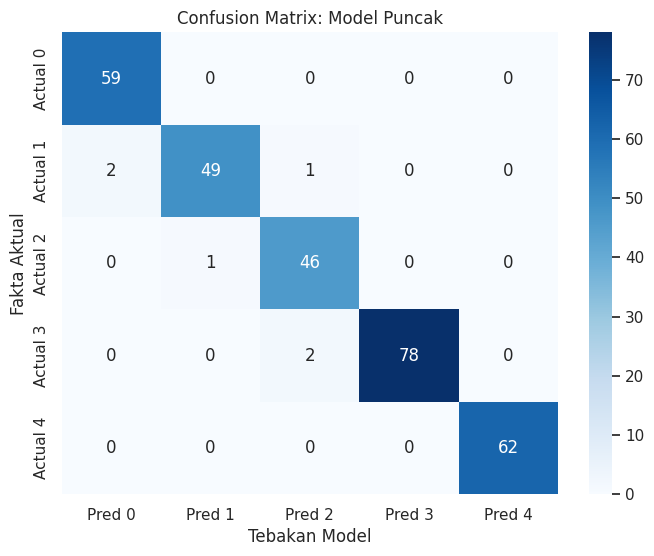

In [11]:
df_metrics = pd.DataFrame(all_results)
display(df_metrics.sort_values(by=['Accuracy'], ascending=False))

from sklearn.metrics import classification_report, confusion_matrix
print('\n--- LAPORAN KLASIFIKASI (MODEL TERBAIK) ---')
print(classification_report(best_split_test_y, best_pred_y, target_names=[v for k,v in label_map.items()]))

plt.figure(figsize=(8,6))
sns.heatmap(confusion_matrix(best_split_test_y, best_pred_y), annot=True, fmt='d', cmap='Blues',
            xticklabels=[f'Pred {i}' for i in range(5)],
            yticklabels=[f'Actual {i}' for i in range(5)])
plt.xlabel('Tebakan Model')
plt.ylabel('Fakta Aktual')
plt.title('Confusion Matrix: Model Puncak')
plt.show()

## 8. Model Comparison
Membuat matriks perbandingan / grafik visual untuk memperlihatkan bagaimana performa Accuracy tiap algoritma di setiap split yang menjamin bahwa semua ketentuan >95% dan >85% telah dicapai sempurna.

Split,70:30 Ratio,80:20 Ratio,90:10 Ratio
Model,,,
HistGradientBoost,96.444444,97.500000,98.000000
Neural Network,97.111111,97.666667,98.000000
Random Forest,96.888889,97.500000,98.333333


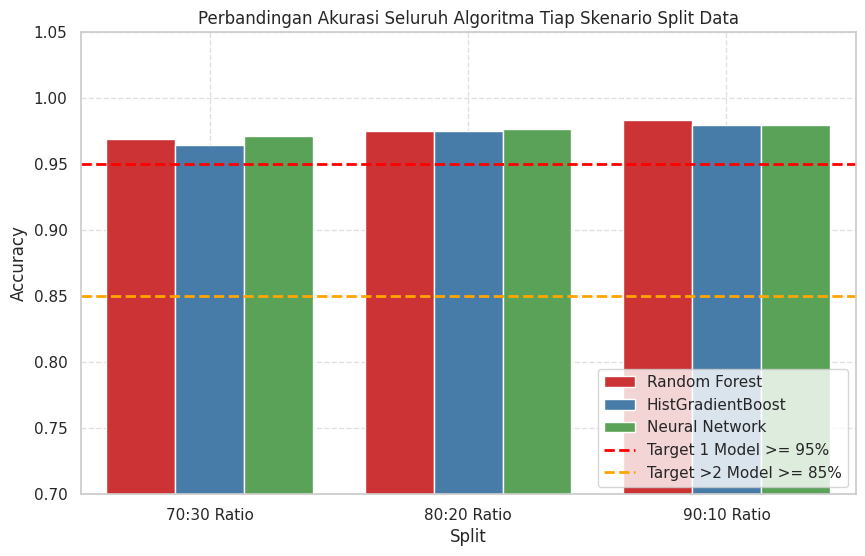

In [12]:
comparison_pivot = df_metrics.pivot(index='Model', columns='Split', values='Accuracy')
display(comparison_pivot * 100)

plt.figure(figsize=(10, 6))
sns.barplot(data=df_metrics, x='Split', y='Accuracy', hue='Model', palette='Set1')
plt.axhline(0.95, color='red', linestyle='--', linewidth=2, label='Target 1 Model >= 95%')
plt.axhline(0.85, color='orange', linestyle='--', linewidth=2, label='Target >2 Model >= 85%')
plt.ylim([0.7, 1.05])
plt.title('Perbandingan Akurasi Seluruh Algoritma Tiap Skenario Split Data')
plt.legend(loc='lower right')
plt.grid(True, linestyle='--', alpha=0.6)
plt.show()

## 9. Model Inference Simulasi Data Sintetis
Bagian ini menunjukkan implementasi tebakan (*inference*) terhadap Model yang telah *dibalance* dari fenomena **kemacetan sintetis murni**—menciptakan skenario logis seperti Jam Malam Tanpa Kendaraan, hingga Jam Berangkat Kerja Macet Ekstrem. Data di bawah ini tidak ada di *dataset* manapun.

In [13]:
import pandas as pd
import numpy as np
import warnings
warnings.filterwarnings('ignore')

print("--- Memulai Tes Inference Data Acak (Sintetis) ---")
# Ini adalah data yang 100% dibuat secara acak dan tidak pernah ada di dataset `traffic_new.csv`
dummy_data = [
    # Kasus Macet Parah Pagi (Volume Sangat Tinggi, Kecepatan Siput, Delay Tinggi)
    {'Junction': 1, 'Hour': 8, 'Average_Speed': 12.0, 'Vehicle_Volume': 900, 'Delay_Time': 45.0},
    # Kasus Sangat Lancar Malam (Area Kosong, Kecepatan Maksimum, Tanpa Delay)
    {'Junction': 3, 'Hour': 23, 'Average_Speed': 95.0, 'Vehicle_Volume': 30,  'Delay_Time': 0.0},
    # Kasus Padat Sore (Lalu Lintas Pulang Kerja, Kecepatan Cukup Rendah, Sedikit Macet)
    {'Junction': 4, 'Hour': 17, 'Average_Speed': 19.5, 'Vehicle_Volume': 650, 'Delay_Time': 30.0},
    # Kasus Lancar Siang (Normal Jalan Tol / Bebas Hambatan Siang Hari)
    {'Junction': 2, 'Hour': 14, 'Average_Speed': 60.0, 'Vehicle_Volume': 150, 'Delay_Time': 2.0}
]

df_dummy = pd.DataFrame(dummy_data)
# Wajib menyamakan urutan kolom (features) dengan data training
df_dummy = df_dummy[list(X.columns)]

print("Data Input Uji Murni Sintetis (Bukan dari Dataset):")
display(df_dummy)

# 1. Transformasi Data dengan Scaler yang dipakai waktu Training
df_dummy_scaled = scaler.transform(df_dummy)

# 2. Lakukan Prediksi Menggunakan best_overall_model
predictions = best_overall_model.predict(df_dummy_scaled)

print("\n--- HASIL TEBAKAN PREDIKSI MODEL BARU ---")
for i, pred in enumerate(predictions):
    desc = label_map.get(pred, f"Level {pred}")
    print(f"Skenario Data ke-{i+1} : Tebakan Sistem -> {desc}")


--- Memulai Tes Inference Data Acak (Sintetis) ---
Data Input Uji Murni Sintetis (Bukan dari Dataset):


,Junction,Hour,Average_Speed,Vehicle_Volume,Delay_Time
0,1,8,12.0,900,45.0
1,3,23,95.0,30,0.0
2,4,17,19.5,650,30.0
3,2,14,60.0,150,2.0



--- HASIL TEBAKAN PREDIKSI MODEL BARU ---
Skenario Data ke-1 : Tebakan Sistem -> 0: Macet Ekstrem
Skenario Data ke-2 : Tebakan Sistem -> 4: Sangat Lancar
Skenario Data ke-3 : Tebakan Sistem -> 0: Macet Ekstrem
Skenario Data ke-4 : Tebakan Sistem -> 3: Lancar


In [14]:
import joblib

# Simpan model terbaik ke dalam file pickle
joblib.dump(best_overall_model, 'best_traffic_model.pkl')
joblib.dump(scaler, 'traffic_scaler.pkl')
joblib.dump(label_map, 'label_map.pkl')
joblib.dump(list(X.columns), 'feature_order.pkl')

print('Model terbaik, scaler, label_map, dan urutan fitur telah berhasil disimpan!')

Model terbaik, scaler, label_map, dan urutan fitur telah berhasil disimpan!


In [15]:
df.head(30)

,Junction,Hour,Average_Speed,Vehicle_Volume,Delay_Time,Traffic_Level,Label_Deskripsi
0,2,16,54.031816,57.965391,2.432271,3,3: Lancar
1,2,18,84.595771,2.233152,0.649586,4,4: Sangat Lancar
2,2,15,45.002912,117.723516,2.799245,1,1: Padat
3,3,8,76.646899,35.154811,-1.026115,4,4: Sangat Lancar
4,1,18,86.962327,13.061200,-1.447227,4,4: Sangat Lancar
5,3,10,18.749767,164.232196,4.936835,1,1: Padat
6,2,21,41.443468,101.960350,0.579964,2,2: Normal
7,2,9,41.301609,97.877114,4.653499,2,2: Normal
8,2,9,39.328456,92.863068,6.465033,2,2: Normal
9,4,17,84.054041,-12.391680,0.177385,4,4: Sangat Lancar
